In [1]:
from torch.utils.data import Dataset
from PIL import Image, UnidentifiedImageError
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = torch.device('cpu')
print(device)

cuda


In [4]:
import os
import json
from PIL import Image
from torch.utils.data import Dataset
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

class VideoFrameDataset(Dataset):
    def __init__(self, frame_root_dir, label_root_dir, transform=None):
        self.frame_root_dir = frame_root_dir
        self.transform = transform
        self.keypoints = []
        self.labels = []

        video_folders = sorted(os.listdir(frame_root_dir))
        for video_folder in video_folders:
            video_path = os.path.join(frame_root_dir, video_folder)
            label_file = os.path.join(label_root_dir, f'{video_folder}.txt')
            
            if not os.path.exists(label_file):
                continue
            
            with open(label_file, 'r') as f:
                labels = f.readlines()

            labels = labels[1:]  # Skip first line
            
            frame_files = sorted(os.listdir(video_path))
            for i, frame_file in enumerate(frame_files):
                if i >= len(labels):
                    break

                frame_json_path = os.path.join(video_path, frame_file)
                with open(frame_json_path, 'r') as f:
                    frame_data = json.load(f)
                
                keypoints = self.extract_keypoints(frame_data)
                if keypoints is None:
                    continue  # skip if no keypoints
                
                label_parts = labels[i].strip().split(',')
                valence = label_parts[0]
                arousal = label_parts[1]
                if valence == '-5' or arousal == '-5':
                    continue  # If label=-5, skip it

                self.keypoints.append(keypoints)
                self.labels.append([float(valence), float(arousal)])

    def extract_keypoints(self, data):
        """从单个帧的 JSON 数据中提取关键点"""
        if 'people' in data and data['people']:
            person_data = data['people'][0]  # take first keypoints of first person
            pose_keypoints = person_data.get('pose_keypoints_2d', [])
            face_keypoints = person_data.get('face_keypoints_2d', [])
            return pose_keypoints + face_keypoints
        return None

    def __len__(self):
        return len(self.keypoints)

    def __getitem__(self, idx):
        keypoints = self.keypoints[idx]
        keypoints_tensor = torch.tensor(keypoints, dtype=torch.float32)
        label = self.labels[idx]
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return keypoints_tensor, label_tensor




train_dataset = VideoFrameDataset(frame_root_dir='F:\\out\\Takeout\\Drive\\batch1-json', label_root_dir='F:\\Aff-Wild2\\5th_ABAW_Annotations\\mini_va\\train')
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

val_dataset = VideoFrameDataset(frame_root_dir='F:\\out\\Takeout\\Drive\\batch1-json', label_root_dir='F:\\Aff-Wild2\\5th_ABAW_Annotations\\mini_va\\valid')
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


In [7]:
class EmotionalStateNN(nn.Module):
    def __init__(self):
        super(EmotionalStateNN, self).__init__()
        self.fc1 = nn.Linear(285, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc_valence = nn.Linear(64, 1)  # Output for valence
        self.fc_arousal = nn.Linear(64, 1)  # Output for arousal

    def forward(self, x):
        # x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        valence = self.fc_valence(x)
        arousal = self.fc_arousal(x)
        return valence, arousal

# Initialize the network, loss function, and optimizer
net = EmotionalStateNN()
criterion = nn.MSELoss()
optimizer = optim.SGD(net.parameters(), lr=0.00001)

# Function to train the model
def ccc(y_true, y_pred):
    mean_true = torch.mean(y_true)
    mean_pred = torch.mean(y_pred)
    var_true = torch.var(y_true)
    var_pred = torch.var(y_pred)
    covariance = torch.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = 2 * covariance / (var_true + var_pred + (mean_true - mean_pred) ** 2)
    return ccc

def train_model(train_loader, val_loader, model, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    train_cccs, val_cccs = [], []

    for epoch in range(epochs):
        model.train()
        running_train_loss, running_train_ccc = 0.0, 0.0
        num_batches = 0

        for inputs, targets in train_loader:
            optimizer.zero_grad()
            valence, arousal = model(inputs)
            loss = criterion(valence, targets[:, 0]) + criterion(arousal, targets[:, 1])
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)
            running_train_ccc += ccc(targets[:, 0], valence) + ccc(targets[:, 1], arousal)
            num_batches += 1

        train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        train_cccs.append(running_train_ccc / (2 * num_batches))  # average each batch CCC

        model.eval()
        running_val_loss, running_val_ccc = 0.0, 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                valence, arousal = model(inputs)
                val_loss = criterion(valence, targets[:, 0]) + criterion(arousal, targets[:, 1])
                running_val_loss += val_loss.item() * inputs.size(0)
                running_val_ccc += ccc(targets[:, 0], valence) + ccc(targets[:, 1], arousal)

        val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)
        val_cccs.append(running_val_ccc / (2 * len(val_loader)))  # average each batch CCC

        print(f'Epoch {epoch+1}, Training Loss: {train_loss}, Training CCC: {train_cccs[-1]}, Validation Loss: {val_loss}, Validation CCC: {val_cccs[-1]}')

    return train_losses, val_losses, train_cccs, val_cccs


# Train the model and plot results
train_losses, val_losses, train_cccs, val_cccs = train_model(train_loader, val_loader, net, criterion, optimizer, epochs=20)


Epoch 1, Training Loss: 0.8088496817520395, Training CCC: -1.0041466790011722e-11, Validation Loss: 0.39692142524978774, Validation CCC: 1.7238876992564656e-11
Epoch 2, Training Loss: 0.3061556330185564, Training CCC: -7.140509971498288e-12, Validation Loss: 0.3697192289847197, Validation CCC: -1.5951325330054722e-11
Epoch 3, Training Loss: 0.2981735463586253, Training CCC: 5.289092948335128e-12, Validation Loss: 0.38073563979174074, Validation CCC: -6.720739850057944e-12
Epoch 4, Training Loss: 0.2938604801439942, Training CCC: 3.378704922177983e-13, Validation Loss: 0.3564255532092791, Validation CCC: 1.3438409456403844e-13
Epoch 5, Training Loss: 0.2908560729123427, Training CCC: -3.1745165849327017e-13, Validation Loss: 0.3569474315373749, Validation CCC: 5.053453315528866e-12
Epoch 6, Training Loss: 0.2886564574111516, Training CCC: 2.491450622199576e-12, Validation Loss: 0.3413877391917343, Validation CCC: 1.0069791354927471e-11
Epoch 7, Training Loss: 0.28706333286791036, Traini

: 

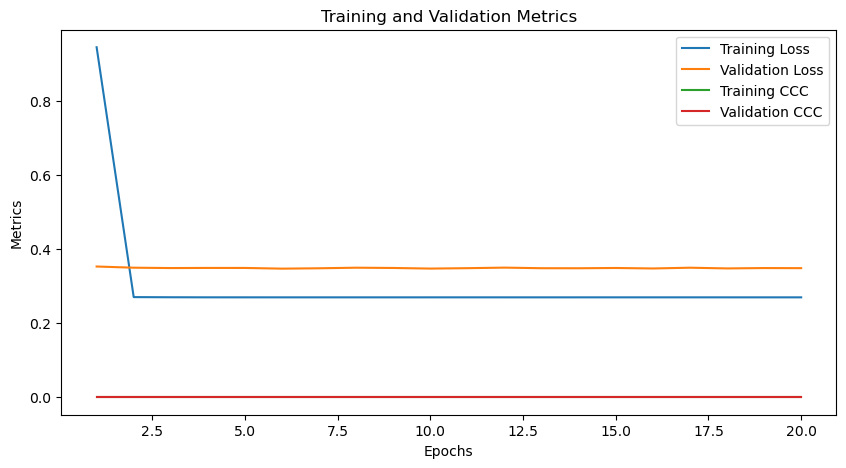

In [ ]:
train_cccs_np = [x.detach().numpy() for x in train_cccs]  # transfer to cpu
val_cccs_np = [x.detach().numpy() for x in val_cccs]

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), train_losses, label='Training Loss')
plt.plot(range(1, 21), val_losses, label='Validation Loss')
plt.plot(range(1, 21), train_cccs_np, label='Training CCC')
plt.plot(range(1, 21), val_cccs_np, label='Validation CCC')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Training and Validation Metrics')
plt.legend()
plt.show()